In [13]:

import torch
#collections是python一个内置模块，提供了一些有用的数据结构
from collections import OrderedDict  #这个类是字典dict的一个子类，用于创建有序的字典。普通字典中元素顺序是无序的，在OrderedDict中元素的顺序是有序的，元素的顺序是按照它们被添加到字典中的顺序决定的。

from pyDOE import lhs #`pyDOE`是一个Python库，用于设计实验。它提供了一些函数来生成各种设计，如因子设计、拉丁超立方设计等。`lhs`是库中的一个函数，全名为"Latin Hypercube Sampling"，拉丁超立方采样。这是一种统计方法，用于生成一个近似均匀分布的多维样本点集。它在参数空间中生成一个非常均匀的样本，这对于高维数值优化问题非常有用，因为它可以更好地覆盖参数空间。
import numpy as np
import matplotlib.pyplot as plt
import scipy.io #导入了scipy库中的io模块。scipy.io模块包含了一些用于文件输入/输出的函数，例如读取和写入.mat文件（MATLAB格式）
from scipy.interpolate import griddata #`scipy.interpolate`是`scipy`库中的一个模块，提供了许多插值工具，用于在给定的离散数据点之间进行插值和拟合。`griddata`是这个模块中的一个函数，用于在无规则的数据点上进行插值。

import random

import skopt #用于优化问题的库，特别是机器学习中的超参数优化
from distutils.version import LooseVersion #distutils是Python的一个标准库，用于构建和安装Python包。LooseVersion是一个类，用于比较版本号


# from plotting_torch import newfig, savefig #从自定义的plotting_torch.py文件中导入了newfig和savefig函数。这两个函数用于创建和保存图形。这两个函数的定义在plotting_torch.py文件中

from mpl_toolkits.axes_grid1 import make_axes_locatable #`mpl_toolkits.axes_grid1`是`matplotlib`库的一个模块，提供了一些高级的工具来控制matplotlib图形中的坐标轴和颜色条。`make_axes_locatable`是模块中的一个函数，用于创建一个可分割的坐标轴。可以在这个坐标轴的四个方向（上、下、左、右）添加新的坐标轴或颜色条。
import matplotlib.gridspec as gridspec #是`matplotlib`库的一个模块，用于创建一个网格布局来放置子图。在`matplotlib`中可以创建一个或多个子图（subplot），每个子图都有自己的坐标轴，并可以在其中绘制图形。`gridspec`模块提供了一个灵活的方式来创建和放置子图。
import time #一个内置模块，用于处理时间相关的操作。


from tqdm import tqdm #一个快速，可扩展的python进度条库，可以在python长循环中添加一个进度提示信息，用户只需要封装任意的迭代器tqdm(iterator)。

import os
import pickle

import timeit #用于计时和测量小段代码的执行时间
import seaborn as sns  # 导入seaborn库用于绘制密度图
import pandas as pd #一个用于数据操作和分析的库，提供了数据结构和数据分析工具，特别是用于处理表格数据（类似于Excel中的数据表）

import sys #导入sys模块。sys模块提供了一些变量和函数，用于与 Python解释器进行交互和访问。例如，sys.path 是一个 Python 在导入模块时会查找的路径列表，sys.argv 是一个包含命令行参数的列表，sys.exit() 函数可以用于退出 Python 程序。导入 sys 模块后，你就可以在你的程序中使用这些变量和函数了。
sys.path.insert(0, '../..') #在 Python的sys.path列表中插入一个新的路径。sys.path是一个 Python 在导入模块时会查找的路径列表。新的路径'../../Utilities/'相对于当前脚本的路径。当你尝试导入一个模块时，Python 会在 sys.path 列表中的路径下查找这个模块。通过在列表开始位置插入一个路径，你可以让 Python 优先在这个路径下查找模块。这在你需要导入自定义模块或者不在 Python 标准库中的模块时非常有用。
from util import *

In [14]:
torch.cuda.set_device(1) #设置当前使用的GPU设备。这里设置为1号GPU设备（第二块显卡）。

# CUDA support 

#设置pytorch的设备，代表了在哪里执行张量积算，设备可以是cpu或者cuda（gpu），并将这个做运算的设备对象存储在变量device中，后续张量计算回在这个设备上执行
if torch.cuda.is_available():
    device = torch.device('cuda')
else:
    device = torch.device('cpu')

In [15]:
import gc
import math
import torch
import torch.nn as nn
from einops import rearrange, repeat
from util import get_clones
import torch.nn.functional as F

class WaveAct(nn.Module):
    def __init__(self):
        super(WaveAct, self).__init__() 
        self.w1 = nn.Parameter(torch.ones(1), requires_grad=True)
        self.w2 = nn.Parameter(torch.ones(1), requires_grad=True)

    def forward(self, x):
        return self.w1 * torch.sin(x)+ self.w2 * torch.cos(x)

class PScan(torch.autograd.Function):
    """

    An implementation of the parallel scan operation in PyTorch (Blelloch version).
    This code is based on Francois Fleuret’s pscan (all credits to him). However, the keys differences are :
    -it has been written in an iterative way (rather than recursive)
    -the backward pass has been rewritten

    Please see docs/pscan.ipynb for a detailed explanation of what happens here.

    Example:
    pscan = PScan.apply

    x = torch.randn(2, 3, 4, 5, requires_grad=True)
    y = torch.randn(2, 3, 4, 5, requires_grad=True)

    model = pscan(x, y)
    model.sum().backward()
    print(x.grad)
    print(y.grad)

    """

    @staticmethod
    def pscan(A, X):
        # A : (B, D, L, N)
        # X : (B, D, L, N)

        # modifies X in place by doing a parallel scan.
        # more formally, X will be populated by these values :
        # H[t] = A[t] * H[t-1] + X[t] with H[0] = 0
        # which are computed in parallel (2*log2(T) sequential steps (ideally), instead of T sequential steps)

        B, D, L, _ = A.size()
        num_steps = int(math.log2(L))

        # up sweep or reduction step
        Aa = A
        Xa = X
        for k in range(num_steps):
            T = 2 * (Xa.size(2) // 2)

            Aa = Aa[:, :, :T].view(B, D, T // 2, 2, -1)
            Xa = Xa[:, :, :T].view(B, D, T // 2, 2, -1)

            abc = Aa[:, :, :, 1].mul(Xa[:, :, :, 0]).detach()
            Xa[:, :, :, 1].add_(abc)
            Aa[:, :, :, 1].mul_(Aa[:, :, :, 0])

            Aa = Aa[:, :, :, 1]
            Xa = Xa[:, :, :, 1]

        # down sweep
        for k in range(num_steps - 1, -1, -1):
            Aa = A[:, :, 2**k - 1 : L : 2**k]
            Xa = X[:, :, 2**k - 1 : L : 2**k]

            T = 2 * (Xa.size(2) // 2)

            if T < Xa.size(2):
                bcd = Aa[:, :, -1].mul(Xa[:, :, -2]).detach()
                Xa[:, :, -1].add_(bcd)
                Aa[:, :, -1].mul_(Aa[:, :, -2])

            Aa = Aa[:, :, :T].view(B, D, T // 2, 2, -1)
            Xa = Xa[:, :, :T].view(B, D, T // 2, 2, -1)

            cdf=Aa[:, :, 1:, 0].mul(Xa[:, :, :-1, 1]).detach()
            Xa[:, :, 1:, 0].add_(cdf)
            Aa[:, :, 1:, 0].mul_(Aa[:, :, :-1, 1])


    @staticmethod
    def forward(ctx, A_in, X_in):
        """
        Applies the parallel scan operation, as defined above. Returns a new tensor.

        Args:
            A_in : (B, L, D, N)
            X_in : (B, L, D, N)

        Returns:
            H : (B, L, D, N)
        """

        # clone tensor (in-place ops)
        A = A_in.clone()  # (B, L, D, N)
        X = X_in.clone()  # (B, L, D, N)

        # prepare tensors
        A = A.transpose(2, 1)  # (B, D, L, N)
        X = X.transpose(2, 1)  # (B, D, L, N)

        # parallel scan
        PScan.pscan(A, X)

        ctx.save_for_backward(A_in, X)

        
        return X.transpose(2, 1)

    @staticmethod
    def backward(ctx, grad_output_in):
        """
        Flows the gradient from the output to the input. Returns two new tensors.

        Args:
            ctx : A_in : (B, L, D, N), X : (B, D, L, N)
            grad_output_in : (B, L, D, N)

        Returns:
            gradA : (B, L, D, N), gradX : (B, L, D, N)
        """

        A_in, X = ctx.saved_tensors

        # clone tensors
        A = A_in.clone()
        # grad_output_in will be cloned with flip()

        # prepare tensors
        A = A.transpose(2, 1)  # (B, D, L, N)
        A = torch.cat((A[:, :, :1], A[:, :, 1:].flip(2)), dim=2)
        grad_output_b = grad_output_in.transpose(2, 1)

        # reverse parallel scan
        grad_output_b = grad_output_b.flip(2)
        PScan.pscan(A, grad_output_b)
        grad_output_b = grad_output_b.flip(2)

        Q = torch.zeros_like(X)
        Q[:, :, 1:].add_(X[:, :, :-1] * grad_output_b[:, :, 1:])

        
        

        return Q.transpose(2, 1), grad_output_b.transpose(2, 1)


pscan = PScan.apply


class SSM(nn.Module):
    def __init__(self, in_features, dt_rank, dim_inner, d_state):
        super().__init__()
        self.dt_rank = dt_rank
        self.dim_inner = dim_inner
        self.d_state = d_state

        self.deltaBC_layer = nn.Linear(in_features, dt_rank + 2 * d_state, bias=True)
        self.dt_proj_layer = nn.Linear(dt_rank, dim_inner, bias=True)

        self.A_log = nn.Parameter(torch.log(torch.arange(1, d_state + 1, dtype=torch.float32).repeat(dim_inner, 1)))
        self.D = nn.Parameter(torch.ones(dim_inner))

    def forward(self, x, pscan=True):
        A = -torch.exp(self.A_log.float())
        D = self.D.float()

        deltaBC = self.deltaBC_layer(x)
        delta, B, C = torch.split(deltaBC, [self.dt_rank, self.d_state, self.d_state], dim=-1)
        delta = F.softplus(self.dt_proj_layer(delta))

        #if pscan:
        #    y = self.selective_scan(x, delta, A, B, C, D)
        #else:
        y = self.selective_scan_seq(x, delta, A, B, C, D)

        return y

    def selective_scan(self, x, delta, A, B, C, D):
        _, L, _ = x.shape

        deltaA = torch.exp(delta.unsqueeze(-1) * A)
        deltaB = delta.unsqueeze(-1) * B.unsqueeze(2)
        BX = deltaB * x.unsqueeze(-1)

        hs = pscan(deltaA, BX)

        y = (hs @ C.unsqueeze(-1)).squeeze() + D * x

        return y

    def selective_scan_seq(self, x, delta, A, B, C, D):
        _, L, _ = x.shape

        deltaA = torch.exp(delta.unsqueeze(-1) * A)
        deltaB = delta.unsqueeze(-1) * B.unsqueeze(2)
        BX = deltaB * x.unsqueeze(-1)

        h = torch.zeros(x.size(0), self.dim_inner, self.d_state, device=deltaA.device)
        hs = []

        for t in range(L):
            h = deltaA[:, t] * h + BX[:, t]
            hs.append(h)

        hs = torch.stack(hs, dim=1)
        y = (hs @ C.unsqueeze(-1)).squeeze() + D * x

        return y

class EncoderLayer(nn.Module):
    def __init__(self, d_model, heads, dt_rank=32, dim_inner=None, d_state=None):
        super().__init__()
        
        self.ssm = SSM(d_model, dt_rank, dim_inner, d_state)
        self.act1 = WaveAct()
        self.act2 = WaveAct()
        self.z_proj = nn.Linear(d_model, d_model)
        self.x_proj = nn.Linear(d_model, d_model)
        self.out_proj = nn.Linear(d_model, d_model)
        self.conv1d = nn.Conv1d(d_model, d_model, 1)
        self.softplus = nn.Softplus()
        #self.layernorm = nn.LayerNorm(d_model)

    def forward(self, x):
        skip = x
        #x = self.layernorm(x)
        
        z = self.z_proj(x)
        z = self.act1(z)
        x = self.x_proj(x)
        x = rearrange(x, "b s d -> b d s")
        x = self.softplus(self.conv1d(x))
        x = rearrange(x, "b d s -> b s d")
        #x = self.layernorm(x)
        x = self.act2(x)
        x = self.ssm(x)

        x = x * z
        x = self.out_proj(x)
        x = skip + x
        #x2 = self.act2(x)
        #x2 = self.layernorm(x2)
        #x = x + self.ff(x2)

        
        

        return x

class FeedForward(nn.Module):
    def __init__(self, d_model, d_ff=256):
        super().__init__()
        self.linear = nn.Sequential(
            nn.Linear(d_model, d_ff),
            WaveAct(),
            nn.Linear(d_ff, d_ff),
            WaveAct(),
            nn.Linear(d_ff, d_model)
        )

    def forward(self, x):
        return self.linear(x)
    

class Encoder(nn.Module):
    def __init__(self, d_model, N, heads):
        super().__init__()
        self.N = N
        self.layers = get_clones(EncoderLayer(d_model, heads, 8, 32, 8), N)
        self.act = WaveAct()
        

    def forward(self, x):
        for i in range(self.N):
            x = self.layers[i](x)
            
        return self.act(x)
    



class Model(nn.Module):
    def __init__(self, in_dim, out_dim, hidden_dim, num_layer, hidden_d_ff=512, heads=2):
        super(Model, self).__init__()

        self.linear_emb = nn.Linear(in_dim, hidden_dim)

        self.encoder = Encoder(hidden_dim, num_layer, heads)
        self.linear_out = nn.Sequential(*[
            nn.Linear(hidden_dim, hidden_d_ff),
            WaveAct(),
            nn.Linear(hidden_d_ff, hidden_d_ff),
            WaveAct(),
            nn.Linear(hidden_d_ff, out_dim)
        ])

    def forward(self, x, t):
        src = torch.cat((x, t), dim=-1)
        src = self.linear_emb(src)
        #d_output = self.decoder(src, src)
        e_outputs = self.encoder(src)
        
        #output = self.linear_out(d_output)
        output = self.linear_out(e_outputs)
        return output


In [16]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import random
from torch.optim import LBFGS,Adam
from tqdm import tqdm
import os
import argparse
from util import *
# from model_dict import get_model

#torch.set_float32_matmul_precision('high')
torch.backends.cuda.matmul.allow_tf32 = False
torch.backends.cudnn.allow_tf32 = False

seed = 0
np.random.seed(seed)
random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed(seed)
step_size = 1e-2
num_step = 7
seq_diff = int(1e-2/step_size)

# # parser = argparse.ArgumentParser('Training Point Optimization')
# parser.add_argument('--model', type=str, default='pinn')
# parser.add_argument('--device', type=str, default='cuda:0')
# args = parser.parse_args()
# device = args.device

res, b_left, b_right, b_upper, b_lower = get_data([0, 2 * np.pi], [0, 1], 101, 101)
res_test, _, _, _, _ = get_data([0, 2 * np.pi], [0, 1], 101, 101)

# if args.model == 'PINNsFormer' or args.model == 'PINNMamba':
res = make_time_sequence(res, num_step=num_step, step=step_size)
b_left = make_time_sequence(b_left, num_step=num_step, step=step_size)
b_right = make_time_sequence(b_right, num_step=num_step, step=step_size)
b_upper = make_time_sequence(b_upper, num_step=num_step, step=step_size)
b_lower = make_time_sequence(b_lower, num_step=num_step, step=step_size)
    
# if args.model == 'PINNsFormer' or args.model == 'PINNMamba':
res_test = make_time_sequence(res_test, num_step=num_step, step=step_size)



res = torch.tensor(res, dtype=torch.float32, requires_grad=True).to(device)
b_left = torch.tensor(b_left, dtype=torch.float32, requires_grad=True).to(device)
b_right = torch.tensor(b_right, dtype=torch.float32, requires_grad=True).to(device)
b_upper = torch.tensor(b_upper, dtype=torch.float32, requires_grad=True).to(device)
b_lower = torch.tensor(b_lower, dtype=torch.float32, requires_grad=True).to(device)

x_res, t_res = res[:, ..., 0:1], res[:, ..., 1:2]
print(res[0,1:3])
print(res[101,0:2])
print(res[202,0:2])
print(x_res.shape)
print(t_res.shape)
x_left, t_left = b_left[:, ..., 0:1], b_left[:, ..., 1:2]
x_right, t_right = b_right[:, ..., 0:1], b_right[:, ..., 1:2]
x_upper, t_upper = b_upper[:, ..., 0:1], b_upper[:, ..., 1:2]
x_lower, t_lower = b_lower[:, ..., 0:1], b_lower[:, ..., 1:2]

print(t_res)
def init_weights(m):
    if isinstance(m, nn.Linear):
        #if(m.bias):
        torch.nn.init.xavier_uniform(m.weight)
        m.bias.data.fill_(0.01)


# if args.model == 'KAN':
#     model = get_model(args).Model(width=[2, 5, 5, 1], grid=5, k=3, grid_eps=1.0, \
#                                   noise_scale_base=0.25, device=device).to(device)
# elif args.model == 'QRes':
#     model = get_model(args).Model(in_dim=2, hidden_dim=256, out_dim=1, num_layer=4).to(device)
#     model.apply(init_weights)
# elif args.model == 'PINNsFormer':
#     model = get_model(args).Model(in_dim=2, hidden_dim=32, out_dim=1, num_layer=1).to(device)
#     model.apply(init_weights)
# elif args.model == 'PINNMamba':
#     model = get_model(args).Model(in_dim=2, hidden_dim=32, out_dim=1, num_layer=1).to(device)
#     model.apply(init_weights)
# else:
#     model = get_model(args).Model(in_dim=2, hidden_dim=512, out_dim=1, num_layer=4).to(device)
#     model.apply(init_weights)

model = Model(in_dim=2, hidden_dim=32, out_dim=1, num_layer=1).to(device) 
model.apply(init_weights)

#optim = Adam(model.parameters(),lr=1e-4)
optim = LBFGS(model.parameters(), line_search_fn='strong_wolfe', tolerance_grad = 1e-8, tolerance_change= 1e-10)
print(model)
print(get_n_params(model))

loss_track = []

for i in tqdm(range(1000)):
    def closure():
        pred_res = model(x_res, t_res)
        #print(pred_res)
        pred_left = model(x_left, t_left)
        pred_right = model(x_right, t_right)
        pred_upper = model(x_upper, t_upper)
        pred_lower = model(x_lower, t_lower)

        u_x = torch.autograd.grad(pred_res, x_res, grad_outputs=torch.ones_like(pred_res), retain_graph=True,   
                                  create_graph=True)#[0]
        u_t = torch.autograd.grad(pred_res, t_res, grad_outputs=torch.ones_like(pred_res), retain_graph=True,
                                  create_graph=True)#[0]
        #print(u_x)

        loss_res = torch.mean((u_t[0] + 50 * u_x[0]) ** 2)
        loss_bc = torch.mean((pred_upper - pred_lower) ** 2)
        loss_ic = torch.mean((pred_left[:,0] - torch.sin(x_left[:,0])) ** 2)
        loss_seq = torch.mean((pred_res[101:10201,0:num_step-seq_diff,:]-pred_res[0:10100,seq_diff:num_step,:]) ** 2)

        #loss_res_detach=loss_res.clone()
        #loss_res_detach.detach()
        #loss_bc_detach=loss_bc.clone()
        #loss_bc_detach.detach()
        #loss_ic_detach=loss_ic.clone()
        #loss_ic_detach.detach()

        loss_track.append([loss_res.item(), loss_bc.item(), loss_ic.item(), loss_seq.item()])
        if i % 20 == 0:
            print('Loss Res: {:4f}, Loss_BC: {:4f}, Loss_IC: {:4f}, Loss_SQ: {:4f}'.format(loss_track[-1][0], loss_track[-1][1], loss_track[-1][2],loss_track[-1][3]))
        loss = loss_res + 10 * loss_bc +  loss_ic + 1000 * loss_seq
        #loss = loss_ic
        optim.zero_grad()
        loss.backward()
        return loss
    
        

    optim.step(closure)



print('Loss Res: {:4f}, Loss_BC: {:4f}, Loss_IC: {:4f}, Loss_SQ: {:4f}'.format(loss_track[-1][0], loss_track[-1][1], loss_track[-1][2],loss_track[-1][3]))
print('Train Loss: {:4f}'.format(np.sum(loss_track[-1])))

if not os.path.exists('./results/'):
    os.makedirs('./results/')


/tmp/ipykernel_3567192/1147274020.py:67: UserWarning: nn.init.xavier_uniform is now deprecated in favor of nn.init.xavier_uniform_.
  torch.nn.init.xavier_uniform(m.weight)


tensor([[0.0000, 0.0100],
        [0.0000, 0.0200]], device='cuda:1', grad_fn=<SliceBackward0>)
tensor([[0.0000, 0.0100],
        [0.0000, 0.0200]], device='cuda:1', grad_fn=<SliceBackward0>)
tensor([[0.0000, 0.0200],
        [0.0000, 0.0300]], device='cuda:1', grad_fn=<SliceBackward0>)
torch.Size([10201, 7, 1])
torch.Size([10201, 7, 1])
tensor([[[0.0000],
         [0.0100],
         [0.0200],
         ...,
         [0.0400],
         [0.0500],
         [0.0600]],

        [[0.0000],
         [0.0100],
         [0.0200],
         ...,
         [0.0400],
         [0.0500],
         [0.0600]],

        [[0.0000],
         [0.0100],
         [0.0200],
         ...,
         [0.0400],
         [0.0500],
         [0.0600]],

        ...,

        [[1.0000],
         [1.0100],
         [1.0200],
         ...,
         [1.0400],
         [1.0500],
         [1.0600]],

        [[1.0000],
         [1.0100],
         [1.0200],
         ...,
         [1.0400],
         [1.0500],
         [1.0600]

  0%|          | 0/1000 [00:00<?, ?it/s]

Loss Res: 11808.098633, Loss_BC: 0.129495, Loss_IC: 12.547474, Loss_SQ: 0.140057
Loss Res: 10528.658203, Loss_BC: 0.119041, Loss_IC: 12.604510, Loss_SQ: 0.139047
Loss Res: 5953.174805, Loss_BC: 0.097395, Loss_IC: 12.414978, Loss_SQ: 0.126176
Loss Res: 3890.688721, Loss_BC: 0.057667, Loss_IC: 12.502151, Loss_SQ: 0.102761
Loss Res: 2722.097656, Loss_BC: 0.053682, Loss_IC: 12.434897, Loss_SQ: 0.086390
Loss Res: 1893.544312, Loss_BC: 0.110965, Loss_IC: 11.702759, Loss_SQ: 0.052179
Loss Res: 1322.799438, Loss_BC: 0.090766, Loss_IC: 11.701280, Loss_SQ: 0.053697
Loss Res: 1017.168152, Loss_BC: 0.124006, Loss_IC: 11.381045, Loss_SQ: 0.042816
Loss Res: 757.057800, Loss_BC: 0.136785, Loss_IC: 10.697516, Loss_SQ: 0.025468
Loss Res: 613.959656, Loss_BC: 0.073564, Loss_IC: 10.470723, Loss_SQ: 0.021024
Loss Res: 465.422058, Loss_BC: 0.016981, Loss_IC: 9.947661, Loss_SQ: 0.015099
Loss Res: 377.285309, Loss_BC: 0.013803, Loss_IC: 9.539040, Loss_SQ: 0.012884
Loss Res: 309.980591, Loss_BC: 0.013275, Los

  2%|▏         | 20/1000 [01:36<1:21:54,  5.01s/it]

...

Loss Res: 0.000009, Loss_BC: 0.000009, Loss_IC: 0.000028, Loss_SQ: 0.000001


 98%|█████████▊| 980/1000 [47:32<00:18,  1.07it/s]

Loss Res: 0.000009, Loss_BC: 0.000009, Loss_IC: 0.000028, Loss_SQ: 0.000001
Loss Res: 0.000009, Loss_BC: 0.000009, Loss_IC: 0.000028, Loss_SQ: 0.000001
Loss Res: 0.000009, Loss_BC: 0.000009, Loss_IC: 0.000028, Loss_SQ: 0.000001
Loss Res: 0.000009, Loss_BC: 0.000009, Loss_IC: 0.000028, Loss_SQ: 0.000001
Loss Res: 0.000009, Loss_BC: 0.000009, Loss_IC: 0.000028, Loss_SQ: 0.000001


100%|██████████| 1000/1000 [47:52<00:00,  2.87s/it]

Loss Res: 0.000009, Loss_BC: 0.000009, Loss_IC: 0.000028, Loss_SQ: 0.000001
Train Loss: 0.000047


relative L1 error: 0.010650
relative L2 error: 0.011575


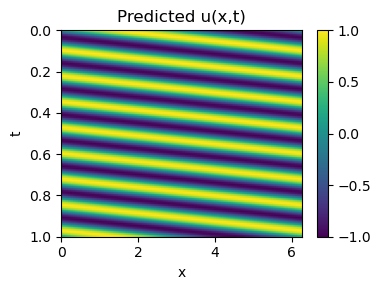

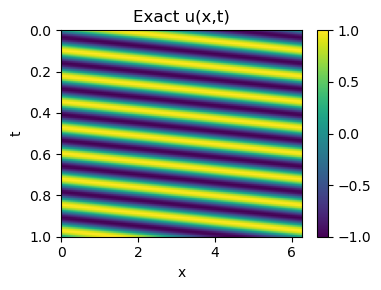

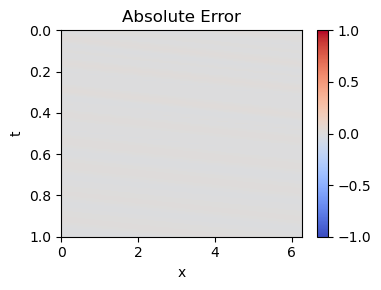

In [17]:

# torch.save(model.state_dict(), f'./results/convection_{args.model}_{num_step}_{step_size}.pt')

# Visualize


res_test = torch.tensor(res_test, dtype=torch.float32, requires_grad=True).to(device)
x_test, t_test = res_test[:, ..., 0:1], res_test[:, ..., 1:2]

#print(t_test)
with torch.no_grad():
    pred = model(x_test, t_test)[:, 0:1]
    #print(pred.shape)
    #pred = model(x_test, t_test)[:, 0:1]
    pred = pred.cpu().detach().numpy()

#print(pred.shape) 
pred = pred.reshape(101, 101)


def u_res(x, t):
    #print(x.shape)
    #print(t.shape)
    return np.sin(x - 50 * t)


res_test, _, _, _, _ = get_data([0, 2 * np.pi], [0, 1], 101, 101)
u = u_res(res_test[:, 0], res_test[:, 1]).reshape(101, 101)

rl1 = np.sum(np.abs(u - pred)) / np.sum(np.abs(u))
rl2 = np.sqrt(np.sum((u - pred) ** 2) / np.sum(u ** 2))

print('relative L1 error: {:4f}'.format(rl1))
print('relative L2 error: {:4f}'.format(rl2))

plt.figure(figsize=(4, 3))
plt.imshow(pred,extent=[0,np.pi*2,1,0], aspect='auto',vmin=-1, vmax=1)
plt.xlabel('x')
plt.ylabel('t')
plt.title('Predicted u(x,t)')
plt.colorbar()
plt.tight_layout()
#plt.axis('off')
# plt.savefig(f'./results/convection_{args.model}_{num_step}_{step_size}_pred.pdf', bbox_inches='tight')

plt.figure(figsize=(4, 3))
plt.imshow(u,extent=[0,np.pi*2,1,0], aspect='auto')
plt.xlabel('x')
plt.ylabel('t')
plt.title('Exact u(x,t)')
plt.colorbar()
plt.tight_layout()
#plt.axis('off')
plt.savefig('./results/convection_exact.pdf', bbox_inches='tight')

plt.figure(figsize=(4, 3))
plt.imshow(pred - u, extent=[0,np.pi*2,1,0], aspect='auto', cmap='coolwarm', vmin=-1, vmax=1)
plt.xlabel('x')
plt.ylabel('t')
plt.title('Absolute Error')
plt.colorbar()
plt.tight_layout()
#plt.axis('off')
# plt.savefig(f'./results/convection_{args.model}_{num_step}_{step_size}_error.pdf', bbox_inches='tight')


In [18]:
model

Model(
  (linear_emb): Linear(in_features=2, out_features=32, bias=True)
  (encoder): Encoder(
    (layers): ModuleList(
      (0): EncoderLayer(
        (ssm): SSM(
          (deltaBC_layer): Linear(in_features=32, out_features=24, bias=True)
          (dt_proj_layer): Linear(in_features=8, out_features=32, bias=True)
        )
        (act1): WaveAct()
        (act2): WaveAct()
        (z_proj): Linear(in_features=32, out_features=32, bias=True)
        (x_proj): Linear(in_features=32, out_features=32, bias=True)
        (out_proj): Linear(in_features=32, out_features=32, bias=True)
        (conv1d): Conv1d(32, 32, kernel_size=(1,), stride=(1,))
        (softplus): Softplus(beta=1, threshold=20)
      )
    )
    (act): WaveAct()
  )
  (linear_out): Sequential(
    (0): Linear(in_features=32, out_features=512, bias=True)
    (1): WaveAct()
    (2): Linear(in_features=512, out_features=512, bias=True)
    (3): WaveAct()
    (4): Linear(in_features=512, out_features=1, bias=True)
  )
)